In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_file_path = '/content/drive/MyDrive/DS-studia/projekt-grupowy/CW03carrier.xlsx'

df = pd.read_excel(
    data_file_path,
    dtype_backend='numpy_nullable',
    skiprows=[0,2],
    na_values=['-'],
)

In [6]:
df.head(5)

,Timestamp,Pallet to Pallet CycleTime (Sec),Serial Number,Part Number,Image,Status,Went Thru Tear Down?,Cycles,Reject Desc,Reject Code,...,M16 DB Diam To A_D-E_B,M15 CC7 Diff Bore Diam,M14 CC15 Shim Perp To G,M13 CC6 PN Side Shim D-E,M12 CC5 RG Side Shim D-E,M11 CC14 Shim Perp To E,M10 Stretch Dist PN Side,M1 CC3 1 Seal Bore,Carrier Housing Part Number,Carrier Gage Cycles
0,2025-01-17 05:21:41.107,202,017250170001,40197696,<NA>,Accept,<NA>,1,<NA>,0,...,0.034,96.885,0.021,83.021,149.814,0.012,100.897,80.017,40197696,1
1,2025-01-17 05:18:19.820,55,017250160213,40211713,<NA>,Accept,<NA>,1,<NA>,0,...,0.027,96.875,0.017,82.791,149.8,0.015,101.01,80.012,40211713,1
2,2025-01-17 05:17:24.213,112,017250160214,40211713,<NA>,Accept,<NA>,1,<NA>,0,...,0.043,96.875,0.042,82.762,149.859,0.008,100.942,80.009,40211713,1
3,2025-01-17 05:15:32.510,299,017250170021,40211713,<NA>,Accept,<NA>,1,<NA>,0,...,0.041,96.871,0.027,82.789,149.815,0.01,101.022,80.026,40211713,1
4,2025-01-17 05:10:33.703,420,017250170025,40211713,<NA>,Accept,<NA>,1,<NA>,0,...,0.082,96.874,0.024,82.807,149.805,0.013,101.008,80.022,40211713,1


In [7]:
n = df.shape[0]
p = df.shape[1]
print(f'samples  n={n}\nfeatures p={p}')

samples  n=13506
features p=65


In [8]:
df.columns

Index(['Timestamp', 'Pallet to Pallet CycleTime (Sec)', 'Serial Number',
       'Part Number', 'Image', 'Status', 'Went Thru Tear Down?', 'Cycles',
       'Reject Desc', 'Reject Code', 'Nest ID Verify Cycles', 'Nest ID Verify',
       'MARPOSS Judge Result', 'M9 Stretch Dist RG Side',
       'M81 DISTANCE 81,0 G', 'M81 DISTANCE 81,0 F', 'M8 CC10 DB Circularity',
       'M7 F Diam To D-E', 'M6 DB Diam To A_D - E_B', 'M58', 'M57', 'M56 P12',
       'M55 P11', 'M54 P6', 'M53 P5', 'M52', 'M51', 'M50',
       'M5 CC9 Diff Bore Diam', 'M45 OFFSET 38,1 G SIDE',
       'M44 OFFSET 38,1 F SIDE', 'M4 SB Diam To F-G/A 2',
       'M37 CC16 F-G To D-E TP', 'M36 OD Flange To D-E TP', 'M35 OD Flange',
       'M34 TD Flange To D-E TP', 'M33 TD Flange Diam',
       'M32 CC2 PN Seal To D-E', 'M31 PN Seal Diam', 'M30 E To A PN TP',
       'M3 SB Diam To F-G/A 1', 'M29 E-D To A-B-C PN TP',
       'M28 PN TB Circularity', 'M27 PN TB Diam', 'M26 PN HB Circularity',
       'M25 CC11 PN HB Diam', 'M24 F-G To 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13506 entries, 0 to 13505
Data columns (total 65 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Timestamp                         13506 non-null  datetime64[ns]
 1   Pallet to Pallet CycleTime (Sec)  13505 non-null  Int64         
 2   Serial Number                     13506 non-null  string        
 3   Part Number                       13506 non-null  string        
 4   Image                             0 non-null      Int64         
 5   Status                            13506 non-null  string        
 6   Went Thru Tear Down?              515 non-null    string        
 7   Cycles                            13506 non-null  Int64         
 8   Reject Desc                       199 non-null    string        
 9   Reject Code                       13506 non-null  Int64         
 10  Nest ID Verify Cycles             13505 non-nu

`Serial Number` i `Part Number` powinny być numerami (a są string) - gdzieś uszkodzone wpisy. Jak wcześniej zostało ustalone, pozwalają na powiązanie danych pomiędzy plikami. (**potencjalne id**)

`Image` brak informacji. Do wyrzucenia.

`Status` zmienna kategorialna - bardzo interesująca, być może zmienna `target`.

`Reject Desc` opis, może się przydać, ale raczej nie jest znormalizowana. Możliwe że powtarza binarną informację ze `Status`

`Reject Code` opis odrzutu ale znormalizowany. Bardzo ciekawe. Może korelować z innymi zmiennymi które wskazują na przekroczenia tolerancji lub są predyktorami odrzutu.

In [10]:
print(f'Więcej niż 1000 braków: {df.columns[(df.isnull().sum() > 1000).values]}')
print(f'Więcej niż 1 braków: {df.columns[(df.isnull().sum() > 1).values]}')
print(f'Więcej niż 0 braków: {df.columns[(df.isnull().sum() > 0).values]}')

Więcej niż 1000 braków: Index(['Image', 'Went Thru Tear Down?', 'Reject Desc'], dtype='object')
Więcej niż 1 braków: Index(['Image', 'Went Thru Tear Down?', 'Reject Desc'], dtype='object')
Więcej niż 0 braków: Index(['Pallet to Pallet CycleTime (Sec)', 'Image', 'Went Thru Tear Down?',
       'Reject Desc', 'Nest ID Verify Cycles', 'MARPOSS Judge Result',
       'M9 Stretch Dist RG Side', 'M81 DISTANCE 81,0 G', 'M81 DISTANCE 81,0 F',
       'M8 CC10 DB Circularity', 'M7 F Diam To D-E', 'M6 DB Diam To A_D - E_B',
       'M58', 'M57', 'M56 P12', 'M55 P11', 'M54 P6', 'M53 P5', 'M52', 'M51',
       'M50', 'M5 CC9 Diff Bore Diam', 'M45 OFFSET 38,1 G SIDE',
       'M44 OFFSET 38,1 F SIDE', 'M4 SB Diam To F-G/A 2',
       'M36 OD Flange To D-E TP', 'M35 OD Flange', 'M34 TD Flange To D-E TP',
       'M33 TD Flange Diam', 'M32 CC2 PN Seal To D-E', 'M31 PN Seal Diam',
       'M30 E To A PN TP', 'M3 SB Diam To F-G/A 1', 'M29 E-D To A-B-C PN TP',
       'M28 PN TB Circularity', 'M27 PN TB Diam', 'M

Zapewne jest jakiś jeden wiersz uszkodzony (patrz `0 braków`)

Kolumny `Went Thru Tear Down?` i `Reject Desc` mogą być szczególnie ciekawe i nie należy ich odrzucać. Ewentualnie dla tych kolumn, w miejsce braków należy ustawić jakąś neutralną wartość.

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,13506,2024-11-21 00:37:13.377362432,2024-10-01 06:09:27.163000,2024-10-26 03:08:16.290249984,2024-11-21 06:16:36.760000,2024-12-11 22:50:59.922749952,2025-01-17 05:21:41.107000,NaN
Pallet to Pallet CycleTime (Sec),13505.0,690.731877,23.0,159.0,273.0,500.0,1133689.0,11237.770507
Image,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
Cycles,13506.0,1.017992,1.0,1.0,1.0,1.0,4.0,0.144664
Reject Code,13506.0,3.654894,0.0,0.0,0.0,0.0,273.0,29.679503
Nest ID Verify Cycles,13505.0,0.99926,0.0,1.0,1.0,1.0,2.0,0.029801
Nest ID Verify,13506.0,2.437731,0.0,1.0,2.0,3.0,4.0,1.147608
MARPOSS Judge Result,13505.0,1.142318,0.0,1.0,1.0,1.0,2.0,0.35108
M9 Stretch Dist RG Side,13505.0,168.012128,167.763,167.97,168.02,168.055,168.189,0.05956
"M81 DISTANCE 81,0 G",13505.0,81.001715,80.941,80.988,81.002,81.015,81.185,0.019062


# Podsumowanie

- `Timestamp` - Data,czas; dane z 107 dni
- `Serial Number` i `Part Number` zanieczyszczone nienumerycznymi danymi
- `Image` nienadaje się przez brak danych (NA w całej kolumnie)
- `Pallet to Pallet CycleTime (Sec)` - braki



---



# Szczegółowa analiza

Nie ma po co zaglądać tutaj :)

In [25]:
for col_name in df.columns:
  print(f'\n{"_"*20}{col_name}{"_"*20}')
  print(f'---Unique:\n{df[col_name].unique()}')
  print(f'---Counts:\n{df[col_name].value_counts()}')
  print()


____________________Timestamp____________________
---Unique:
<DatetimeArray>
['2025-01-17 05:21:41.107000', '2025-01-17 05:18:19.820000',
 '2025-01-17 05:17:24.213000', '2025-01-17 05:15:32.510000',
 '2025-01-17 05:10:33.703000', '2025-01-17 05:03:33.820000',
 '2025-01-17 05:02:35.880000', '2025-01-17 04:55:24.113000',
 '2025-01-17 04:47:08.110000', '2025-01-17 04:44:46.063000',
 ...
 '2024-10-01 07:14:47.233000', '2024-10-01 07:12:45.330000',
 '2024-10-01 07:04:39.820000', '2024-10-01 06:59:29.533000',
 '2024-10-01 06:56:45.740000', '2024-10-01 06:45:08.620000',
 '2024-10-01 06:40:16.017000', '2024-10-01 06:24:08.283000',
 '2024-10-01 06:12:07.763000', '2024-10-01 06:09:27.163000']
Length: 13506, dtype: datetime64[ns]
---Counts:
Timestamp
2024-10-01 06:09:27.163    1
2025-01-17 05:21:41.107    1
2024-10-01 08:31:09.360    1
2024-10-01 08:33:05.417    1
2024-10-01 08:34:30.863    1
                          ..
2025-01-17 05:02:35.880    1
2025-01-17 05:03:33.820    1
2025-01-17 05:10:

Timestamp intervals
max:    13 days 02:54:48.706000
min:    0 days 00:00:23.607000
median: 0 days 00:04:33.290000
Intervals quantiles
0.25   0 days 00:02:38.690000
0.50   0 days 00:04:33.290000
0.75   0 days 00:08:19.670000
Name: Timestamp, dtype: timedelta64[ns]


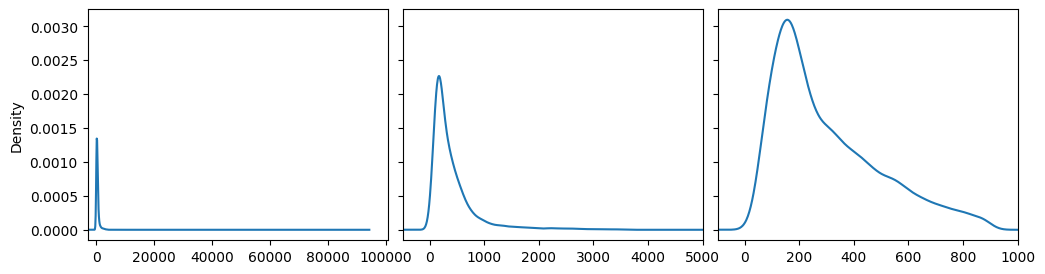

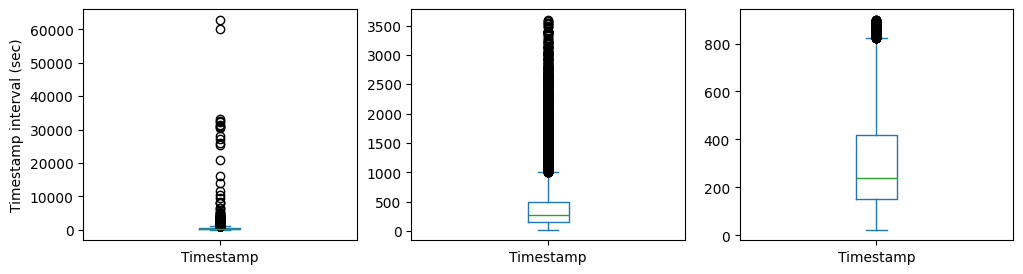

In [76]:
df['Timestamp'].max() - df['Timestamp'].min()
interval = df['Timestamp'][::-1].diff()
print(f'Timestamp intervals\n{"max:":<8}{interval.max()}\n{"min:":<8}{interval.min()}\n{"median:":<8}{interval.median()}')
print(f'Intervals quantiles\n{interval.quantile([.25,.5,.75])}')
int_sec = interval.dt.seconds
int_sec_1h = interval[interval < "01:00:00"].dt.seconds
int_sec_15min = interval[interval < "00:15:00"].dt.seconds
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,3), sharey=True)
fig.subplots_adjust(wspace=0.05)
int_sec.plot(kind='kde', ax=axs[0], xlim=(-3000))
int_sec_1h.plot(kind='kde', ax=axs[1], xlim=(-500,5000))
int_sec_15min.plot(kind='kde', ax=axs[2], xlim=(-100,1000))
plt.show()

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,3))
int_sec.plot(kind='box', ax=axs[0], ylabel='Timestamp interval (sec)')
int_sec_1h.plot(kind='box', ax=axs[1])
int_sec_15min.plot(kind='box', ax=axs[2])
plt.show()

Badanie interwałów pomiędzy kolejnymi timestamp-ami. Wykresy przedstawiają rozkład interwałów jako całość, do 1 godziny, do 15 minut.

Być może uszkodzone elementy mają charakterystyczny czas produkcji? Może warto sprawdzić korelację interwałów z uszkodzonym produktem.

In [12]:
print(df['Status'].unique())
print(df['Status'].value_counts())

<StringArray>
['Accept', 'Reject']
Length: 2, dtype: string
Status
Accept    13304
Reject      202
Name: count, dtype: Int64


In [13]:
print(df['MARPOSS Judge Result'].unique())
print(df['MARPOSS Judge Result'].value_counts())

<IntegerArray>
[1, 2, 0, <NA>]
Length: 4, dtype: Int64
MARPOSS Judge Result
1    11567
2     1930
0        8
Name: count, dtype: Int64
